# 02 - Features e Split Temporal

Objetivo: entender como o projeto separa treino, validação e teste por tempo e como cria features sem vazamento de informação.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config.settings import Settings
from src.data.load_data import RawDataRepository
from src.data.merge_data import FraudDataMerger
from src.data.split_data import TemporalSplitter
from src.features.cleaning import FraudDataCleaner
from src.features.feature_engineering import FraudFeatureEngineer
from src.features.preprocessing import build_preprocessor, columns_to_drop

pd.set_option("display.max_columns", 120)
sns.set_theme(style="whitegrid")
settings = Settings(project_root=PROJECT_ROOT)

## 1. Preparar dataset consolidado

In [3]:
raw = RawDataRepository(settings).load_all()
merged = FraudDataMerger(settings).merge(
    transactions=raw["transactions"],
    cards=raw["cards"],
    users=raw["users"],
    mcc_codes=raw["mcc"],
    labels=raw["labels"],
)
cleaned = FraudDataCleaner(settings).fit_transform(merged)
cleaned.shape

2026-06-13 12:34:38 | INFO | src.data.load_data | Carregando CSV de local: D:\developer\workspace_python\financial_transactions_pipeline\data\raw\transactions_data.csv
2026-06-13 12:35:46 | INFO | src.data.load_data | Carregando CSV de local: D:\developer\workspace_python\financial_transactions_pipeline\data\raw\cards_data.csv
2026-06-13 12:35:46 | INFO | src.data.load_data | Carregando CSV de local: D:\developer\workspace_python\financial_transactions_pipeline\data\raw\users_data.csv
2026-06-13 12:35:46 | INFO | src.data.load_data | Carregando JSON de local: D:\developer\workspace_python\financial_transactions_pipeline\data\raw\mcc_codes.json
2026-06-13 12:35:46 | INFO | src.data.load_data | Carregando JSON de local: D:\developer\workspace_python\financial_transactions_pipeline\data\raw\train_fraud_labels.json
2026-06-13 12:38:03 | INFO | src.data.merge_data | Dataset consolidado: 8914963 linhas, 39 colunas


D:\developer\workspace_python\financial_transactions_pipeline\src\features\cleaning.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column] = pd.to_datetime(df[column], errors="coerce")
D:\developer\workspace_python\financial_transactions_pipeline\src\features\cleaning.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column] = pd.to_datetime(df[column], errors="coerce")


(8914963, 39)

## 2. Split temporal

O teste fica no período mais recente. O threshold é escolhido na validação, nunca no teste.

In [4]:
splits = TemporalSplitter(settings).split(cleaned)

split_summary = pd.DataFrame(
    [
        {"split": "train", "rows": len(splits.train), "start": splits.train[splits.time_column].min(), "end": splits.train[splits.time_column].max(), "fraud_rate": splits.train[settings.target_column].mean()},
        {"split": "validation", "rows": len(splits.validation), "start": splits.validation[splits.time_column].min(), "end": splits.validation[splits.time_column].max(), "fraud_rate": splits.validation[settings.target_column].mean()},
        {"split": "test", "rows": len(splits.test), "start": splits.test[splits.time_column].min(), "end": splits.test[splits.time_column].max(), "fraud_rate": splits.test[settings.target_column].mean()},
    ]
)
split_summary

,split,rows,start,end,fraud_rate
0,train,6240474,2010-01-01 00:01:00,2016-12-22 06:26:00,0.001630
1,validation,1337244,2016-12-22 06:26:00,2018-05-27 07:00:00,0.000606
2,test,1337245,2018-05-27 07:00:00,2019-10-31 23:57:00,0.001760


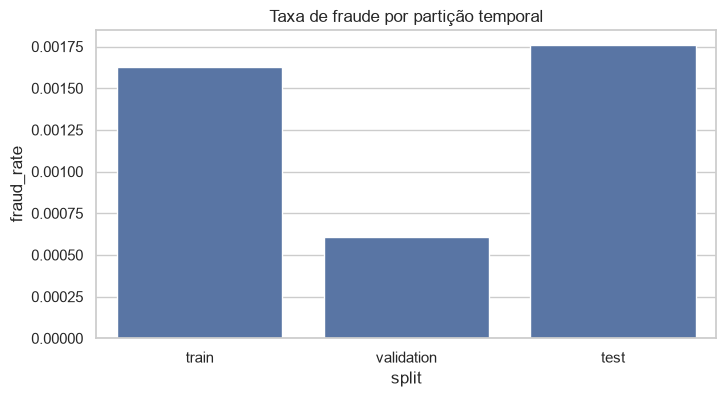

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=split_summary, x="split", y="fraud_rate", ax=ax)
ax.set_title("Taxa de fraude por partição temporal")
ax.set_ylabel("fraud_rate")
plt.show()

## 3. Engenharia de features sem dados futuros

O transformer calcula features comportamentais com `shift(1)`, isto é, usando transações anteriores ao registro atual.

In [6]:
X_train = splits.train.drop(columns=[settings.target_column])
X_val = splits.validation.drop(columns=[settings.target_column])

feature_engineer = FraudFeatureEngineer(settings)
train_features = feature_engineer.fit_transform(X_train)
val_features = feature_engineer.transform(X_val)

created_columns = sorted(set(train_features.columns) - set(X_train.columns))
created_columns

['amount_abs',
 'amount_log1p',
 'amount_mean_5_prev',
 'amount_std_5_prev',
 'amount_to_mean_5_prev',
 'is_night',
 'is_weekend',
 'previous_amount',
 'transaction_dayofweek',
 'transaction_hour',
 'transaction_month',
 'transactions_seen_before']

In [7]:
preview_columns = [col for col in ["amount", "previous_amount", "amount_mean_5_prev", "amount_std_5_prev", "amount_to_mean_5_prev", "transactions_seen_before"] if col in train_features.columns]
train_features[preview_columns].head(10)

,amount,previous_amount,amount_mean_5_prev,amount_std_5_prev,amount_to_mean_5_prev,transactions_seen_before
0,-77.00,NaN,NaN,NaN,NaN,0
1,14.57,NaN,NaN,NaN,NaN,0
2,80.00,NaN,NaN,NaN,NaN,0
3,46.41,NaN,NaN,NaN,NaN,0
4,4.81,NaN,NaN,NaN,NaN,0
5,26.46,NaN,NaN,NaN,NaN,0
6,3.51,NaN,NaN,NaN,NaN,0
7,2.58,NaN,NaN,NaN,NaN,0
8,39.63,-77.0,-77.0,0.0,-0.514675,2
9,43.33,NaN,NaN,NaN,NaN,0


## 4. Colunas removidas antes do modelo

IDs crus e colunas temporais brutas são removidos. O modelo usa features derivadas, numéricas e categóricas tratadas pelo `ColumnTransformer`.

In [8]:
drop_cols = columns_to_drop(train_features.columns, settings)
drop_cols

['acct_open_date',
 'card_id',
 'card_number',
 'client_id',
 'date',
 'expires',
 'merchant_id',
 'transaction_id']

In [9]:
preprocessor = build_preprocessor(train_features, settings)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per

In [10]:
numeric_cols = preprocessor.transformers[0][2]
categorical_cols = preprocessor.transformers[1][2]

pd.DataFrame(
    {
        "group": ["numeric", "categorical", "drop"],
        "count": [len(numeric_cols), len(categorical_cols), len(drop_cols)],
    }
)

,group,count
0,numeric,26
1,categorical,16
2,drop,8


## 5. Missing values nas features criadas

Nulos em features históricas são esperados para a primeira transação de um cartão/usuário. Eles são tratados por imputação dentro do preprocessador.

In [11]:
feature_missing = (
    train_features[created_columns]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
feature_missing.columns = ["feature", "missing_rate"]
feature_missing

,feature,missing_rate
0,amount_to_mean_5_prev,0.000660
1,amount_std_5_prev,0.000623
2,previous_amount,0.000621
3,amount_mean_5_prev,0.000621
4,amount_abs,0.000000
5,amount_log1p,0.000000
6,is_night,0.000000
7,is_weekend,0.000000
8,transaction_dayofweek,0.000000
9,transaction_hour,0.000000
